TV구독여부/ 영화구독여부/구독기간/평균청구금액/남은계약기간/서비스장애횟수/평균다운로드량/평균업로드량/초과다운로드여부/고객이탈여부[0:유지,1:이탈]

# 데이터 탐색

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df = pd.read_csv('/content/drive/MyDrive/internet_service_churn.csv')
df.shape
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72274 entries, 0 to 72273
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           72274 non-null  int64  
 1   is_tv_subscriber             72274 non-null  int64  
 2   is_movie_package_subscriber  72274 non-null  int64  
 3   subscription_age             72274 non-null  float64
 4   bill_avg                     72274 non-null  int64  
 5   reamining_contract           50702 non-null  float64
 6   service_failure_count        72274 non-null  int64  
 7   download_avg                 71893 non-null  float64
 8   upload_avg                   71893 non-null  float64
 9   download_over_limit          72274 non-null  int64  
 10  churn                        72274 non-null  int64  
dtypes: float64(4), int64(7)
memory usage: 6.1 MB


,id,is_tv_subscriber,is_movie_package_subscriber,subscription_age,bill_avg,reamining_contract,service_failure_count,download_avg,upload_avg,download_over_limit,churn
0,15,1,0,11.95,25,0.14,0,8.4,2.3,0,0
1,18,0,0,8.22,0,NaN,0,0.0,0.0,0,1
2,23,1,0,8.91,16,0.00,0,13.7,0.9,0,1
3,27,0,0,6.87,21,NaN,1,0.0,0.0,0,1
4,34,0,0,6.39,0,NaN,0,0.0,0.0,0,1


/tmp/ipython-input-3690580312.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='churn', data=df,palette=['skyblue','orange'])
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


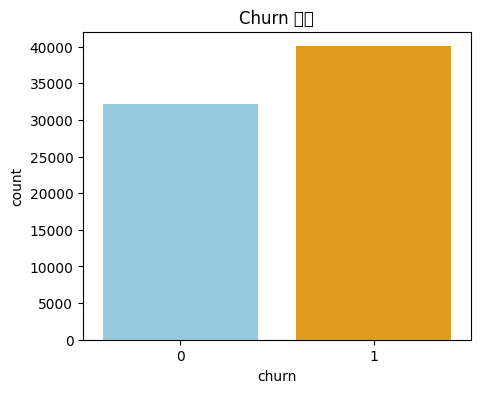

,proportion
churn,
1,55.414118
0,44.585882


In [3]:
# churn 비율확인 [0:유지,1:이탈]
plt.figure(figsize=(5,4))
sns.countplot(x='churn', data=df,palette=['skyblue','orange'])
plt.title("Churn 분포")
plt.show()
df['churn'].value_counts(normalize=True) * 100

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44288 (\N{HANGUL SYLLABLE GWAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


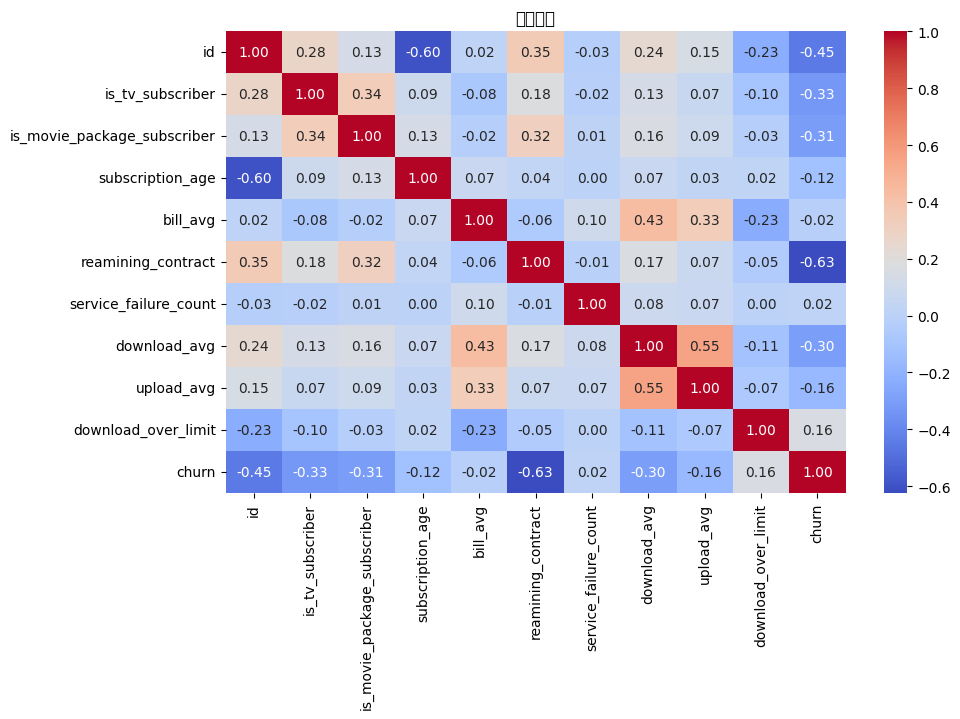

In [4]:
# 상관관계 분석
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("상관관계")
plt.show()

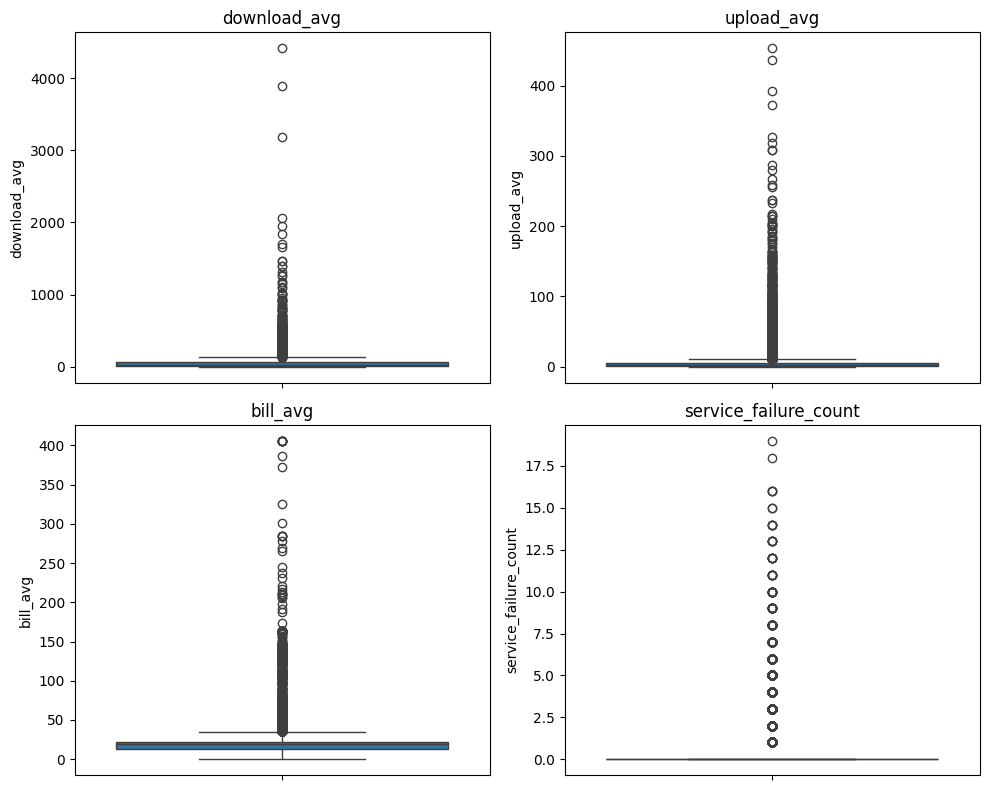

In [5]:
# 이상치 탐색
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

sns.boxplot(df['download_avg'], ax=axes[0,0])
axes[0,0].set_title('download_avg')

sns.boxplot(df['upload_avg'], ax=axes[0,1])
axes[0,1].set_title('upload_avg')

sns.boxplot(df['bill_avg'], ax=axes[1,0])
axes[1,0].set_title('bill_avg')

sns.boxplot(df['service_failure_count'], ax=axes[1,1])
axes[1,1].set_title('service_failure_count')

plt.tight_layout()
plt.show()

# 데이터 전처리

In [6]:
df1 = df.copy()
df1.drop('id', axis=1, inplace=True)  # id 제거
df1.dropna(subset=['download_avg'], inplace=True)  # download_avg 결측치 제거
print(df1['upload_avg'].isna().sum())

0


In [7]:
# reamining_contract 전처리
conditions = [
    df1['reamining_contract'].isnull(),
    df1['reamining_contract'] == 0,
    df1['reamining_contract'] > 0,
]
choices = ['no_contract','expired','active']

df1['contract_type'] = np.select(conditions,choices,default='unknown')
df1.head()

,is_tv_subscriber,is_movie_package_subscriber,subscription_age,bill_avg,reamining_contract,service_failure_count,download_avg,upload_avg,download_over_limit,churn,contract_type
0,1,0,11.95,25,0.14,0,8.4,2.3,0,0,active
1,0,0,8.22,0,NaN,0,0.0,0.0,0,1,no_contract
2,1,0,8.91,16,0.00,0,13.7,0.9,0,1,expired
3,0,0,6.87,21,NaN,1,0.0,0.0,0,1,no_contract
4,0,0,6.39,0,NaN,0,0.0,0.0,0,1,no_contract


In [8]:
# One-hot encoding
df1 = pd.get_dummies(df1,columns=['contract_type'], dtype=int)

In [9]:
# reamining_contract drop
df1 = df1.drop(columns = ['reamining_contract'])
df1.head()

,is_tv_subscriber,is_movie_package_subscriber,subscription_age,bill_avg,service_failure_count,download_avg,upload_avg,download_over_limit,churn,contract_type_active,contract_type_expired,contract_type_no_contract
0,1,0,11.95,25,0,8.4,2.3,0,0,1,0,0
1,0,0,8.22,0,0,0.0,0.0,0,1,0,0,1
2,1,0,8.91,16,0,13.7,0.9,0,1,0,1,0
3,0,0,6.87,21,1,0.0,0.0,0,1,0,0,1
4,0,0,6.39,0,0,0.0,0.0,0,1,0,0,1


In [10]:
# subscription_age 범주화
def age_group(x):
  if x<2:
    return 0
  elif x>=2 and x<4:
    return 1
  elif x>=4 and x<6:
    return 2
  elif x>=6 and x<8:
    return 3
  elif x>=8 and x<10:
    return 4
  elif x>=10:
    return 5
df1['subscription_age'] = df1['subscription_age'].apply(age_group)

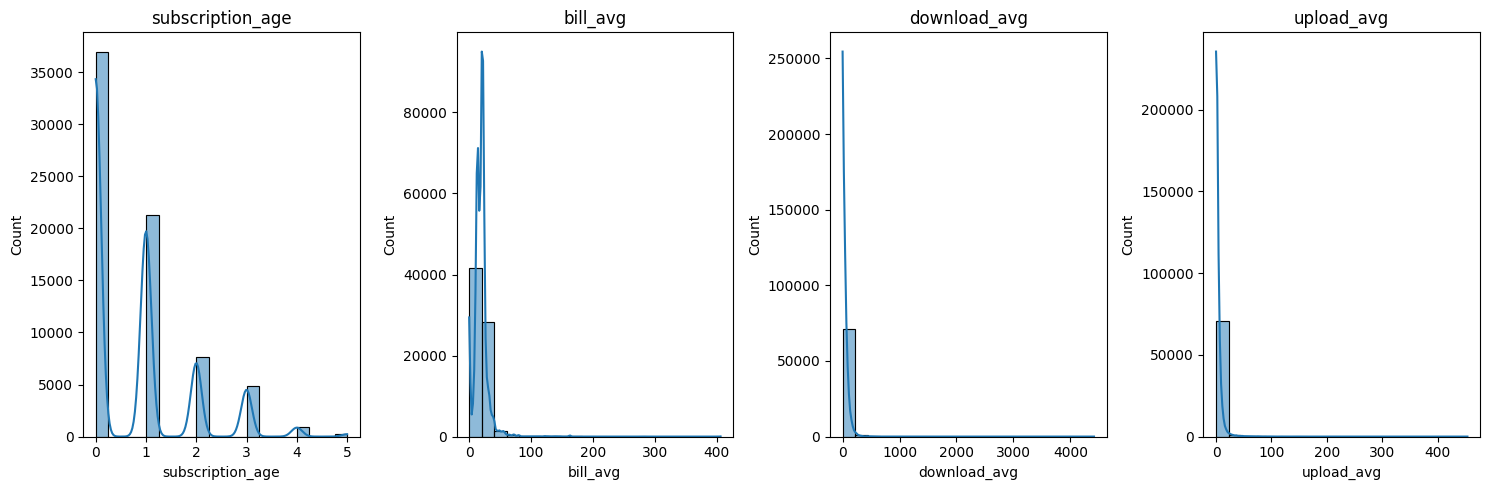

In [11]:
# 수치형변수 데이터분포시각화
selected_cols = ['subscription_age', 'bill_avg', 'download_avg', 'upload_avg']

plt.figure(figsize=(15, 5))
for i, col in enumerate(selected_cols, 1):
    plt.subplot(1, len(selected_cols), i)
    sns.histplot(df1[col], kde=True, bins=20)
    plt.title(col)
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44288 (\N{HANGUL SYLLABLE GWAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


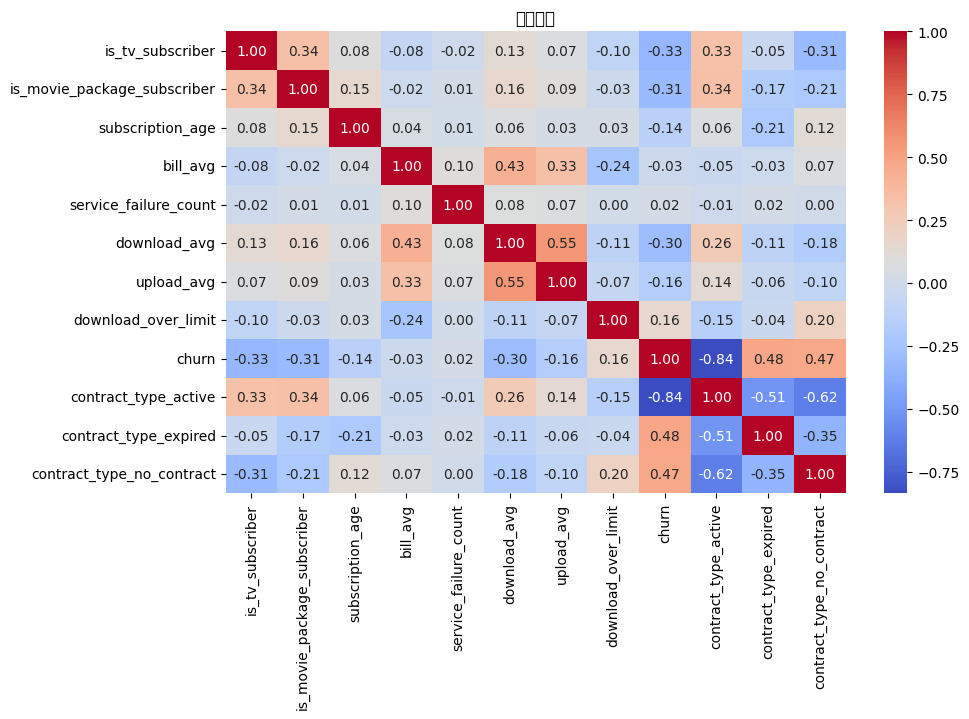

In [12]:
# 1차 전처리 후 상관관계 분석
plt.figure(figsize=(10,6))
sns.heatmap(df1.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("상관관계")
plt.show()

In [13]:
# bill_avg & download_avg , upload_avg
bill_group_medians = df1.groupby(
    pd.qcut(df1['bill_avg'], q=5, duplicates='drop')
)[['download_avg','upload_avg']].median()

print("\nMedian values by avg_bill groups:\n", bill_group_medians)


Median values by avg_bill groups:
                 download_avg  upload_avg
bill_avg                                
(-0.001, 12.0]          12.2         0.9
(12.0, 16.0]            32.8         2.5
(16.0, 21.0]            26.7         2.0
(21.0, 24.0]            24.7         1.9
(24.0, 406.0]           50.7         4.0


/tmp/ipython-input-2100182342.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bill_group_medians = df1.groupby(


In [14]:
# # bill_avg를 5등분해서 그룹화
# df1['bill_group'] = pd.qcut(df1['bill_avg'], q=5, duplicates='drop')

# # 📊 download_avg: bill_group + churn별 비교
# plt.figure(figsize=(10,6))
# sns.boxplot(x='bill_group', y='download_avg', hue='churn', data=df1)
# plt.xlabel('Bill Average Group (Quantiles)')
# plt.ylabel('Download Average')
# plt.title('Download Average by Bill Group and Churn')
# plt.xticks(rotation=45)
# plt.legend(title='Churn', labels=['0 (유지)', '1 (이탈)'])
# plt.show()

# # 📊 upload_avg: bill_group + churn별 비교
# plt.figure(figsize=(10,6))
# sns.boxplot(x='bill_group', y='upload_avg', hue='churn', data=df1)
# plt.xlabel('Bill Average Group (Quantiles)')
# plt.ylabel('Upload Average')
# plt.title('Upload Average by Bill Group and Churn')
# plt.xticks(rotation=45)
# plt.legend(title='Churn', labels=['0 (유지)', '1 (이탈)'])
# plt.show()
